In [58]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

from scipy.signal import welch, decimate
from scipy.optimize import curve_fit

from scipy.fft import rfft, irfft, rfftfreq

In [59]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/gas_collisions/analysis_notebooks/sphere_20260215_final_analysis/../../analysis_utils.py'>

In [60]:
sphere = 'sphere_20260215'

## Calculate chi2 values and derive signal efficiency curve

In [61]:
def get_normalized_template(sphere, bounds=(1250, 1750), downsampled=False):
    pulse_shape_file = np.load(rf'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/pulse_calibration/{sphere}/{sphere}_impulse_recon_combined.npz')
    pulse_shape_template = pulse_shape_file['ps_20v']
    amp2kev = pulse_shape_file['amp2kev']

    normalized_template = pulse_shape_template / np.max(pulse_shape_template)

     # Take the central values around the peak
    ret = normalized_template[bounds[0]:bounds[1]]

    # Downsample to 500 kHz (so the 200 us template has 100 indices)
    if downsampled:
        ret_downsampled = decimate(ret, 10)
        return ret_downsampled / np.max(ret_downsampled), amp2kev
    else:
        return ret, amp2kev

def calc_chisquares_pulse(pulse_shapes, normalized_template, bounds, sigma_amp):
    amp_idx = 1500

    ret = np.empty(pulse_shapes.shape[0])
    for i, pulse_shape in enumerate(pulse_shapes):
        amp = pulse_shape[amp_idx]

        waveform = pulse_shape[bounds[0] : bounds[1]]
        # Amplitude can be negative so no need to adjust for polarity
        template_scaled = amp * normalized_template

        # Sigma should be in amplitude (not keV)
        ret[i] = np.sum( ((waveform - template_scaled)/sigma_amp)**2 )
    return ret

In [62]:
sphere = 'sphere_20260215'
normalized_template, amp2kev = get_normalized_template(sphere, bounds=(1250, 1750), downsampled=False)

# Load individual waveforms and amplitudes saved during calibration
_template_file = np.load(
    rf'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/pulse_calibration/{sphere}/{sphere}_impulse_recon_combined.npz'
)
_voltage_keys = ['2_5v', '5v', '7_5v', '10v', '12_5v', '15v', '17_5v', '20v']
good_pulse_shape_all_datasets = [_template_file[f'ind_{k}'] for k in _voltage_keys]
good_amps_all_datasets        = [_template_file[f'amp_{k}'] for k in _voltage_keys]
good_indices_all_datasets        = [_template_file[f'idx_{k}'] for k in _voltage_keys]
pulse_amp = _template_file['pulse_amp_kev']

sigma_p_amp = 60 / amp2kev
chi2_pulse_all = []
for i, good_pulses in enumerate(good_pulse_shape_all_datasets):
    chi2 = calc_chisquares_pulse(good_pulses, normalized_template, (1250, 1750), sigma_p_amp)
    chi2_pulse_all.append(chi2)

Text(0.5, 1.0, 'sphere_20260215, all calibration')

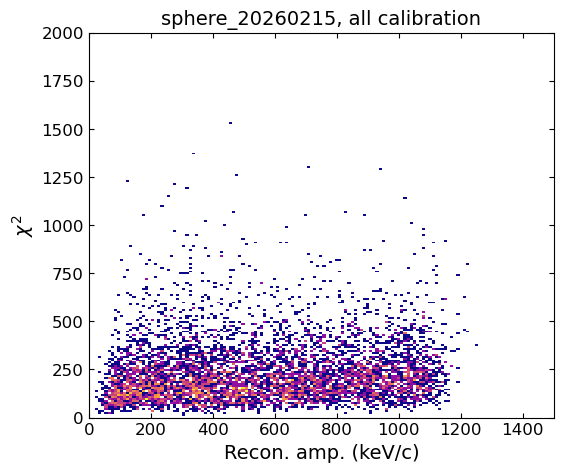

In [65]:
import matplotlib.colors as colors

xbins = np.linspace(0, 2000, 200)
ybins = np.linspace(0, 2000, 200)

_good_amps_all_datasets = np.concatenate(good_amps_all_datasets)
_chi2_all_datasets = np.concatenate(chi2_pulse_all)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

hh, _, _ = np.histogram2d(x=np.abs(_good_amps_all_datasets)*amp2kev, y=_chi2_all_datasets, bins=(xbins, ybins))
pc = ax.pcolormesh(xbins, ybins, hh.T, norm=colors.LogNorm(), cmap='plasma')

ax.set_ylim(0, 2000)
ax.set_xlim(0, 1500)
ax.set_xlabel(r'Recon. amp. (keV/c)', fontsize=14)
ax.set_ylabel(r'$\chi^2$', fontsize=14)
ax.set_title(f'{sphere}, all calibration')

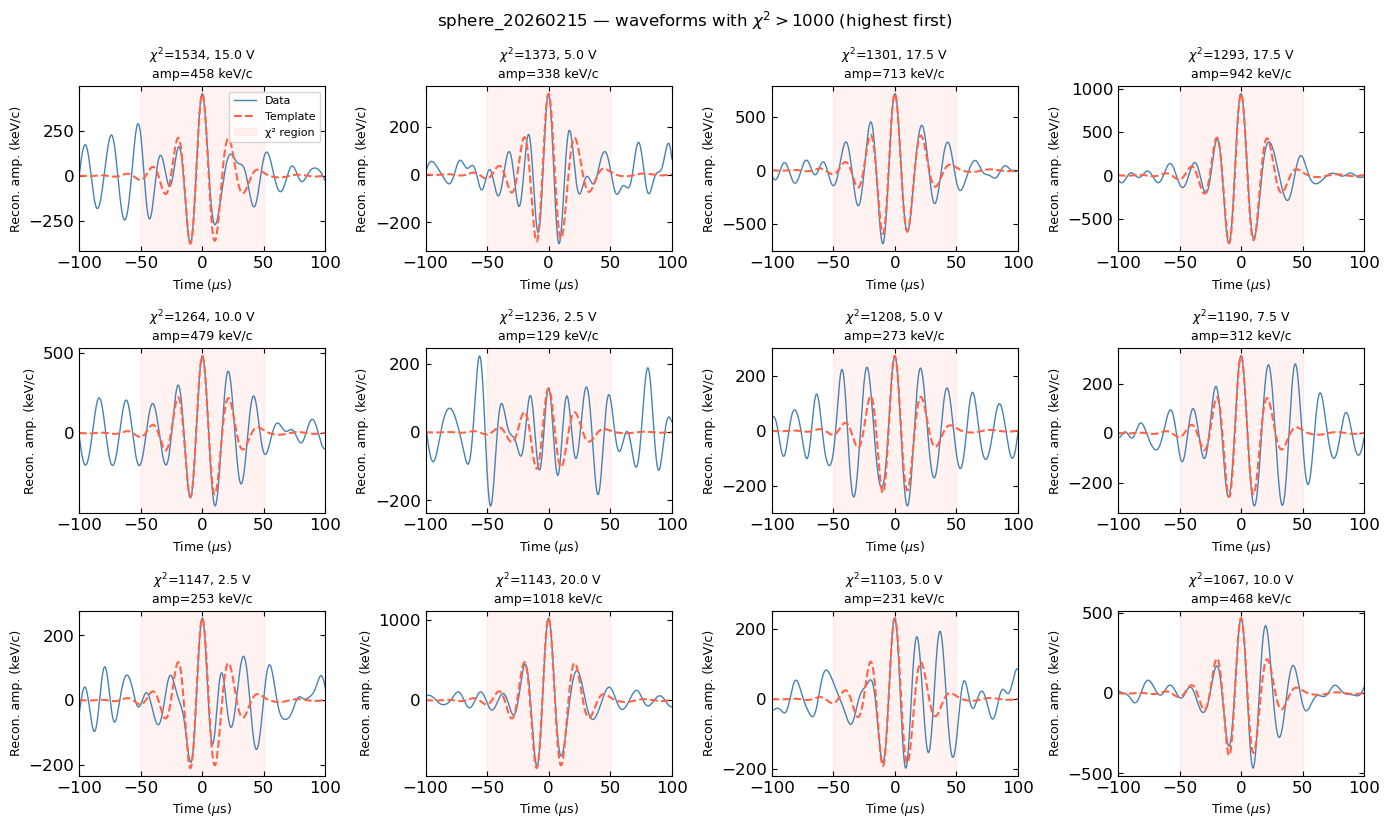

In [68]:
# Plot a few waveforms with chi2 > 1000
chi2_cut = 1000
n_show = 12
tt_us = (np.arange(3000) - 1500) * 200e-9 / 1e-6

chi2_lb, chi2_ub = 1250, 1750   # indices used for chi2 calculation

# Full normalised template (3000 samples) for overlay
_npz = np.load(rf'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/pulse_calibration/{sphere}/{sphere}_impulse_recon_combined.npz')
_ps_full = _npz['ps_20v']
full_template = _ps_full / np.max(_ps_full)

voltages = [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]

high_chi2_pulses, high_chi2_vals, high_chi2_amps, high_chi2_voltages = [], [], [], []
for v, pulses, amps, chi2 in zip(voltages, good_pulse_shape_all_datasets, good_amps_all_datasets, chi2_pulse_all):
    mask = chi2 > chi2_cut
    high_chi2_pulses.append(pulses[mask])
    high_chi2_vals.append(chi2[mask])
    high_chi2_amps.append(amps[mask])
    high_chi2_voltages.append(np.full(mask.sum(), v))

all_high_pulses   = np.concatenate(high_chi2_pulses, axis=0)
all_high_chi2     = np.concatenate(high_chi2_vals)
all_high_amps     = np.concatenate(high_chi2_amps)
all_high_voltages = np.concatenate(high_chi2_voltages)

# Sort by descending chi2
order = np.argsort(all_high_chi2)[::-1]
sel_pulses   = all_high_pulses[order[:n_show]]
sel_chi2     = all_high_chi2[order[:n_show]]
sel_amps     = all_high_amps[order[:n_show]]
sel_voltages = all_high_voltages[order[:n_show]]

ncols = 4
nrows = int(np.ceil(n_show / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8))
for i, ax in enumerate(axes.flatten()):
    if i >= n_show:
        ax.axis('off')
        continue
    amp = sel_amps[i]

    ax.plot(tt_us, sel_pulses[i] * amp2kev, color='steelblue', lw=1, label='Data')
    ax.plot(tt_us, amp * full_template * amp2kev, color='tomato', lw=1.5, ls='--', label='Template')
    ax.axvspan(tt_us[chi2_lb], tt_us[chi2_ub], alpha=0.08, color='tomato', label='χ² region')

    ax.set_title(
        fr'$\chi^2$={sel_chi2[i]:.0f}, {sel_voltages[i]} V'
        '\n'
        fr'amp={sel_amps[i]*amp2kev:.0f} keV/c',
        fontsize=9
    )
    ax.set_xlim(-100, 100)
    ax.set_xlabel(r'Time ($\mu$s)', fontsize=9)
    ax.set_ylabel('Recon. amp. (keV/c)', fontsize=9)
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(fr'{sphere} — waveforms with $\chi^2 > {chi2_cut}$ (highest first)', fontsize=12)
fig.tight_layout()

Average accepctance ratio by the chi2 cut: 0.98 +- 0.01


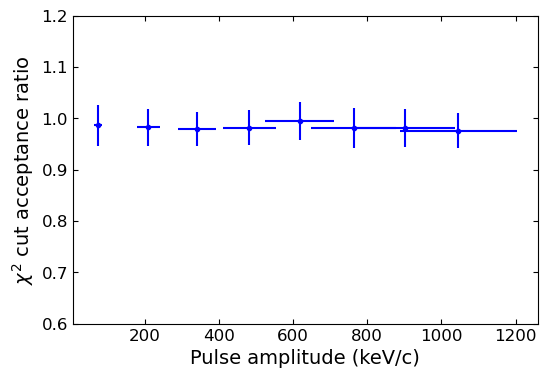

In [80]:
#### Check the fraction of calibration pulses accepted by the chi2 cut
chi2_threshold = 700

frac_accepted, frac_accepted_err = [], []
total_accepted, all_pulses = 0, 0
for chi2 in chi2_pulse_all:
    frac_accepted.append(np.sum(chi2 < chi2_threshold) / chi2.size)
    frac_accepted_err.append(np.sqrt(np.sum(chi2 < chi2_threshold)) / chi2.size)

    total_accepted += np.sum(chi2 < chi2_threshold)
    all_pulses += chi2.size

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(pulse_amp, frac_accepted, xerr=pulse_amp*0.15, yerr=frac_accepted_err, fmt='.', color='b')
ax.set_ylim(0.6, 1.2)
ax.set_ylabel(r'$\chi^2$ cut acceptance ratio')
ax.set_xlabel('Pulse amplitude (keV/c)')

print(f'Average accepctance ratio by the chi2 cut: {total_accepted/all_pulses:.2f} +- {np.sqrt(total_accepted)/all_pulses:.2f}')

#### Signal efficiency by counting calibration pulses based on timing

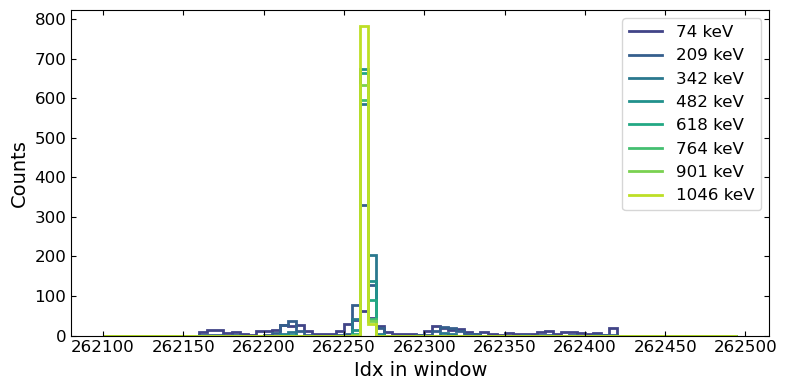

In [81]:
cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0.2, 0.9, 8))

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(262100, 262500, 5)
bc = 0.5 * (bins[1:] + bins[:-1])
hhs_all = []
for i in range(8):
    chi2_mask = chi2_pulse_all[i] < chi2_threshold
    good_idx = good_indices_all_datasets[i][chi2_mask]
    hh, _ = np.histogram(good_idx, bins=bins)
    hhs_all.append(hh)
    ax.stairs(hh, edges=bins, color=colors[i], label=f'{pulse_amp[i]} keV', linewidth=2)

ax.set_xlabel('Idx in window')
ax.set_ylabel('Counts')
ax.legend()
fig.tight_layout()

In [102]:
from scipy.special import erf
def func_eff(x, z, f, a):
    return a * (0.5 * erf((x - z) * f) + 0.5)

# Total counts per voltage without chi2 cut (used as denominator)
hhs_total = []
for i in range(8):
    hh_total, _ = np.histogram(good_indices_all_datasets[i], bins=bins)
    hhs_total.append(hh_total)

good_recon_idx = np.asarray([31, 32, 33, 40, 41, 42])
effs_all, effs_err_all = np.empty(8), np.empty(8)
for i in range(8):
    n_total    = np.sum(hhs_total[i])
    n_accepted = np.sum(hhs_all[i][good_recon_idx])
    effs_all[i]     = n_accepted / n_total
    effs_err_all[i] = np.sqrt(n_accepted) / n_total   # Poisson uncertainty

popt, pcov = curve_fit(func_eff, pulse_amp, effs_all, sigma=effs_err_all,
                       absolute_sigma=True, p0=[60, 0.001, 1.0], maxfev=5000)

n_dof = len(pulse_amp) - len(popt)
residuals = effs_all - func_eff(pulse_amp, *popt)
chi2_red = np.sum((residuals / effs_err_all)**2) / n_dof

print(f'Efficiency coefficients: z={popt[0]:.1f} keV/c, f={popt[1]:.4f}, a={popt[2]:.3f}')
print(f'Reduced chi2: {chi2_red:.2f} (ndof={n_dof})')

Efficiency coefficients: z=126.4 keV/c, f=0.0065, a=0.982
Reduced chi2: 0.04 (ndof=5)


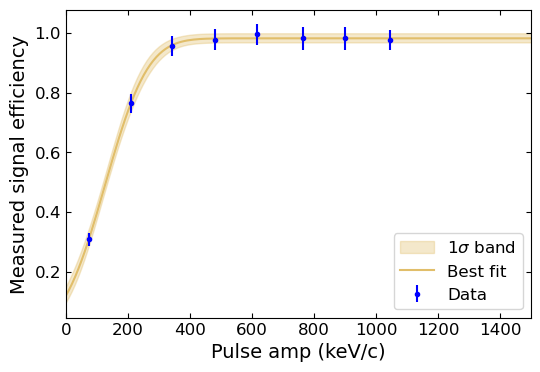

In [103]:
fig, ax = plt.subplots(figsize=(6, 4))

xx = np.linspace(0, 2000, 200)

# Best fit
eff_fit = func_eff(xx, *popt)

# 1-sigma band: error propagation using diagonal variances of pcov
u      = (xx - popt[0]) * popt[1]
dexp   = np.exp(-u**2) / np.sqrt(np.pi)
dfdz   = popt[2] * (-popt[1]) * dexp
dfdf   = popt[2] * (xx - popt[0]) * dexp
dfda   = 0.5 * erf(u) + 0.5
eff_std = np.sqrt(dfdz**2 * pcov[0,0] + dfdf**2 * pcov[1,1] + dfda**2 * pcov[2,2])

ax.fill_between(xx, eff_fit - eff_std, eff_fit + eff_std, color='#E1BE6A', alpha=0.35, label=r'1$\sigma$ band')
ax.plot(xx, eff_fit, '-', color='#E1BE6A', label='Best fit')
ax.errorbar(pulse_amp, effs_all, yerr=effs_err_all, color='b', fmt='.', label='Data', zorder=5)

ax.set_xlim(0, 1500)
ax.set_xlabel('Pulse amp (keV/c)')
ax.set_ylabel('Measured signal efficiency')
ax.legend()

In [104]:
amp2kev

array(14460.84503586)